## Visualize subintervals concepts

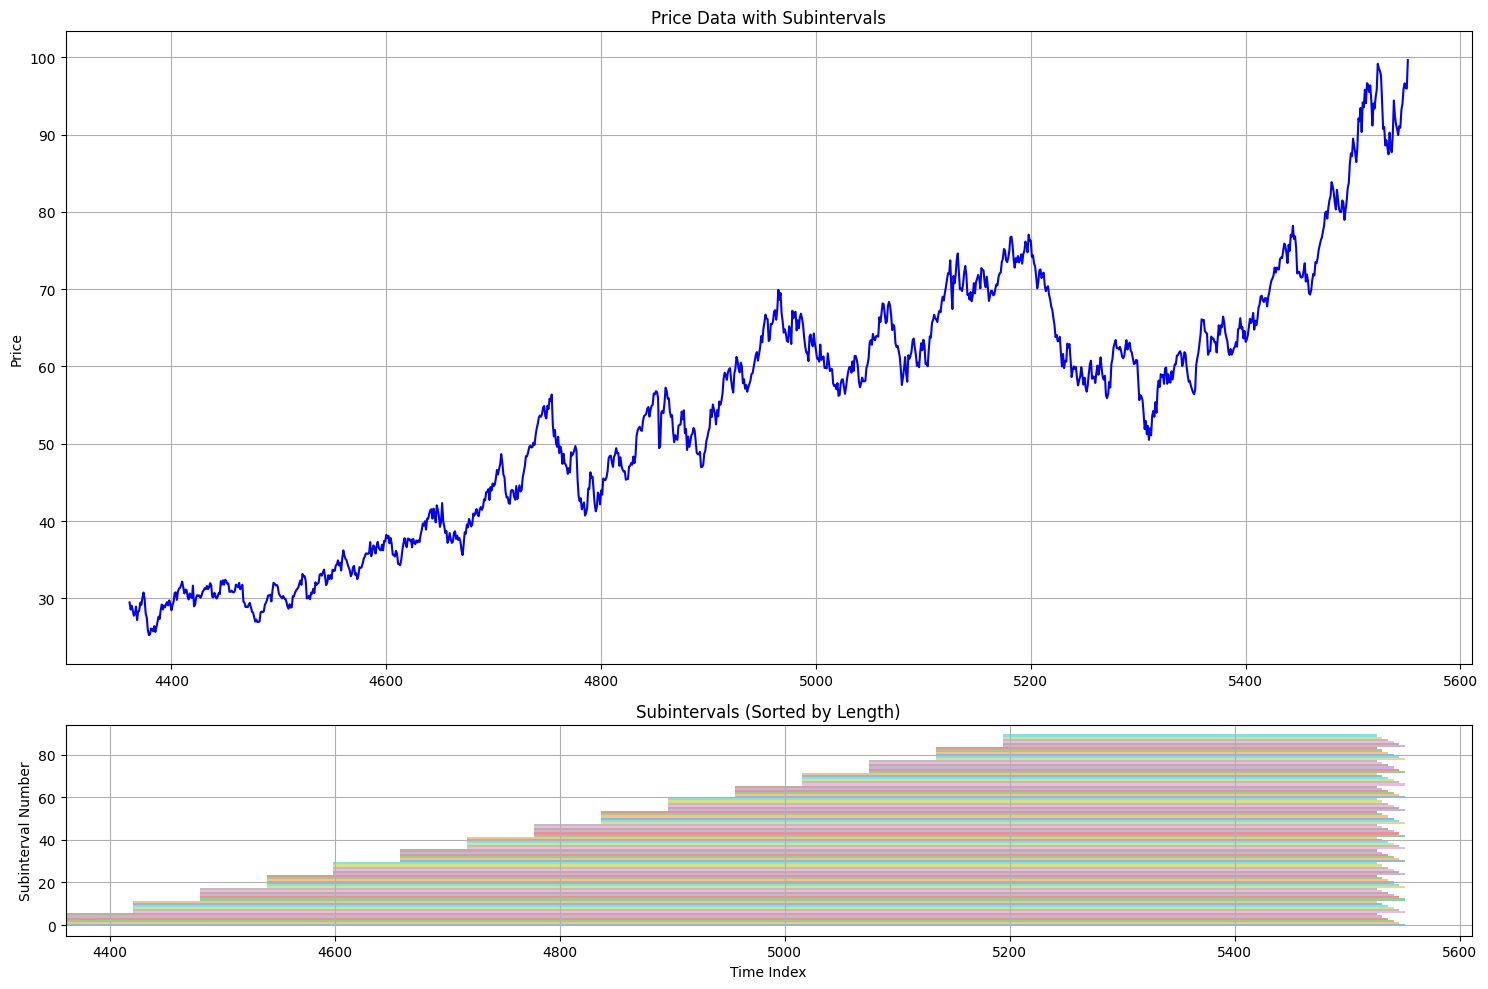

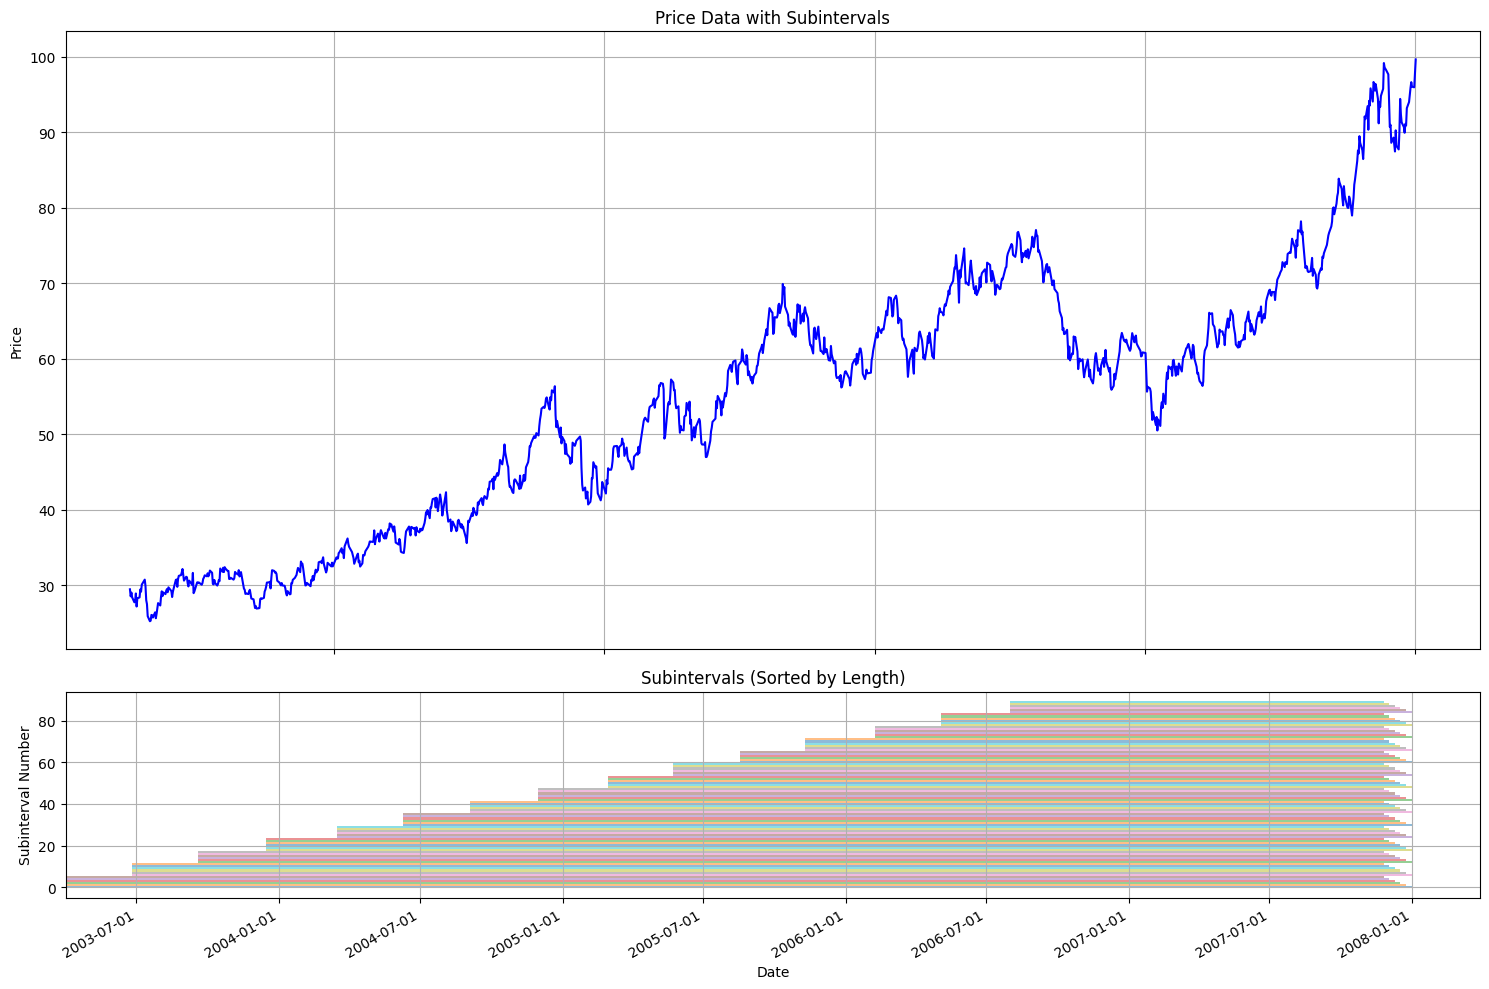

In [4]:

from GQLib.Optimizers import MPGA, PSO, SGA, SA, NELDER_MEAD, TABU, FA
from GQLib.Models import LPPL, LPPLS
from GQLib.enums import InputType
from GQLib.AssetProcessor import AssetProcessor
from GQLib.logging import configure_logger
from GQLib.Framework import Framework
import numpy as np

configure_logger("INFO")

fw = Framework("daily", InputType.WTI) 
sample = fw.select_sample(fw.data, "01/04/2003", "02/01/2008") 
subintervals = fw.generate_subintervals(fw.frequency, sample)

import matplotlib.pyplot as plt
# Create figure and axis#
# Create figure and axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[3, 1])

#
ax1.plot(sample[:, 0], sample[:, 1], 'b-', label='Price')
ax1.set_title('Price Data with Subintervals')
ax1.set_ylabel('Price')
ax1.grid(True)

# Sort subintervals by length (longest first)
sorted_subintervals = sorted(enumerate(subintervals), 
                           key=lambda x: x[1][1] - x[1][0], 
                           reverse=True)

# Plot subintervals as stacked bars in the lower subplot
for i, (orig_idx, (start, end, _)) in enumerate(sorted_subintervals):
    ax2.barh(y=i, width=end-start, left=start, height=1, alpha=0.5, 
             label=f'Original interval {orig_idx+1}')

ax2.set_title('Subintervals (Sorted by Length)')
ax2.set_xlabel('Time Index')
ax2.set_ylabel('Subinterval Number')
ax2.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

def plot_with_dates(subintervals, sample, fw_data):
    # Step 1: Create index-to-date mapping
    index_to_date = dict(zip(fw_data[:, 0].astype(int), pd.to_datetime(fw_data[:, 1])))

    # Convert x-values in sample from index to date
    sample_dates = np.array([index_to_date[int(idx)] for idx in sample[:, 0]])

    # Create figure and axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[3, 1])

    # Plot sample prices with datetime x-axis
    ax1.plot(sample_dates, sample[:, 1], 'b-', label='Price')
    ax1.set_title('Price Data with Subintervals')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Step 2: Sort subintervals by length
    sorted_subintervals = sorted(enumerate(subintervals), 
                                 key=lambda x: x[1][1] - x[1][0], 
                                 reverse=True)

    # Step 3: Plot bars with datetime on x-axis
    for i, (orig_idx, (start, end, _)) in enumerate(sorted_subintervals):
        start_date = index_to_date[int(start)]
        end_date = index_to_date[int(end)]
        duration = (end_date - start_date).days or 1  # fallback if same day
        ax2.barh(y=i, width=duration, left=start_date, height=1, alpha=0.5,
                 label=f'Interval {orig_idx+1}')

    ax2.set_title('Subintervals (Sorted by Length)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Subinterval Number')
    ax2.grid(True)

    # Format x-axis as dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()

    # Adjust layout
    plt.tight_layout()
    plt.show()


plot_with_dates(subintervals, sample, fw.data)

{'tc_distrib': [5547.682998915445, 5553.166296096377, 5567.7650538021635, 5571.43965275713, 5574.015785019867, 5575.1173266097285, 5578.016274677509, 5580.806353283874, 5582.669105507082, 5583.7833684490615, 5583.9905910957405, 5591.097100017184, 5594.634099911409, 5595.248940701601, 5600.379525675753, 5605.252552005143, 5605.544702913089, 5612.388333808402, 5613.826694423923, 5622.8194238848355, 5623.621588176818, 5624.455368773932, 5627.083587457445, 5629.8947540285135, 5635.033343959452, 5635.927843801934, 5641.868637971241, 5641.945896557113, 5645.394117200614, 5647.538298199079, 5650.778039275828, 5653.915608472298, 5655.593328931669, 5656.572612348881, 5662.378068838692, 5664.770494321815, 5664.892049636092, 5668.458974769205, 5671.3329097349715, 5671.933565164322, 5675.7566185899195, 5676.037634234682, 5676.809336757504, 5679.053832685844, 5679.9097909411785, 5679.942811036676, 5685.671197538422, 5694.864624929867, 5697.832057035515, 5703.874065642921, 5718.856927916882, 5718.98

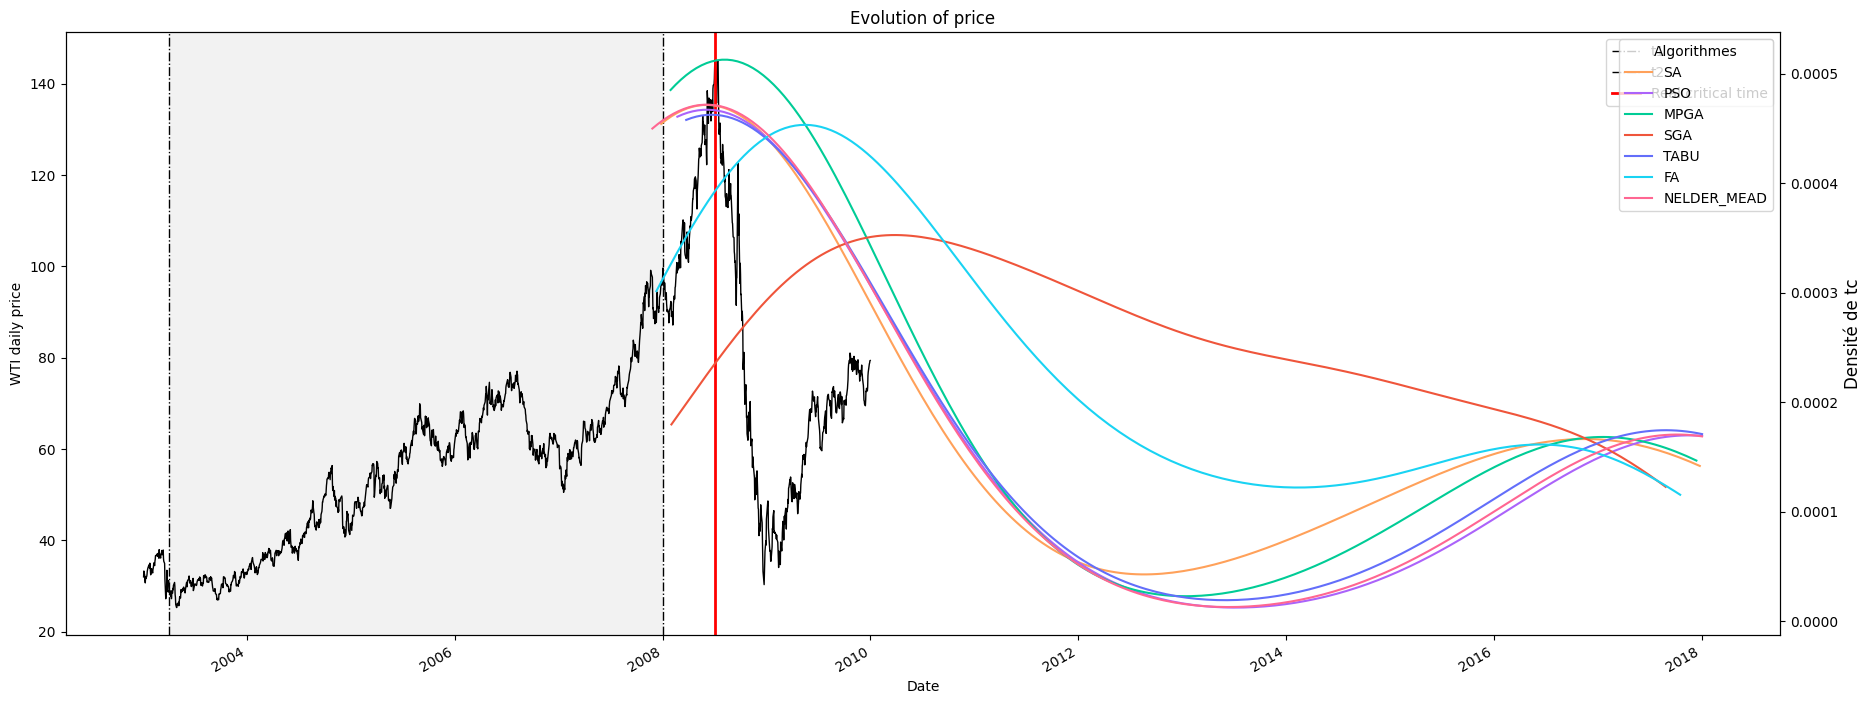

In [1]:
from GQLib.Framework import Framework
from GQLib.enums import InputType
import json

fw = Framework("daily", InputType.WTI)

fig, axes = fw._base("01/04/2003", "02/01/2008", "03/07/2008")

with open("Venise_Results/WTI_metrics.json", "r") as f:
    data = json.load(f)

fw._add_kernels(fig, axes, data["Set 1"])



TypeError: Framework._add_half_violins() got an unexpected keyword argument 'end_date'

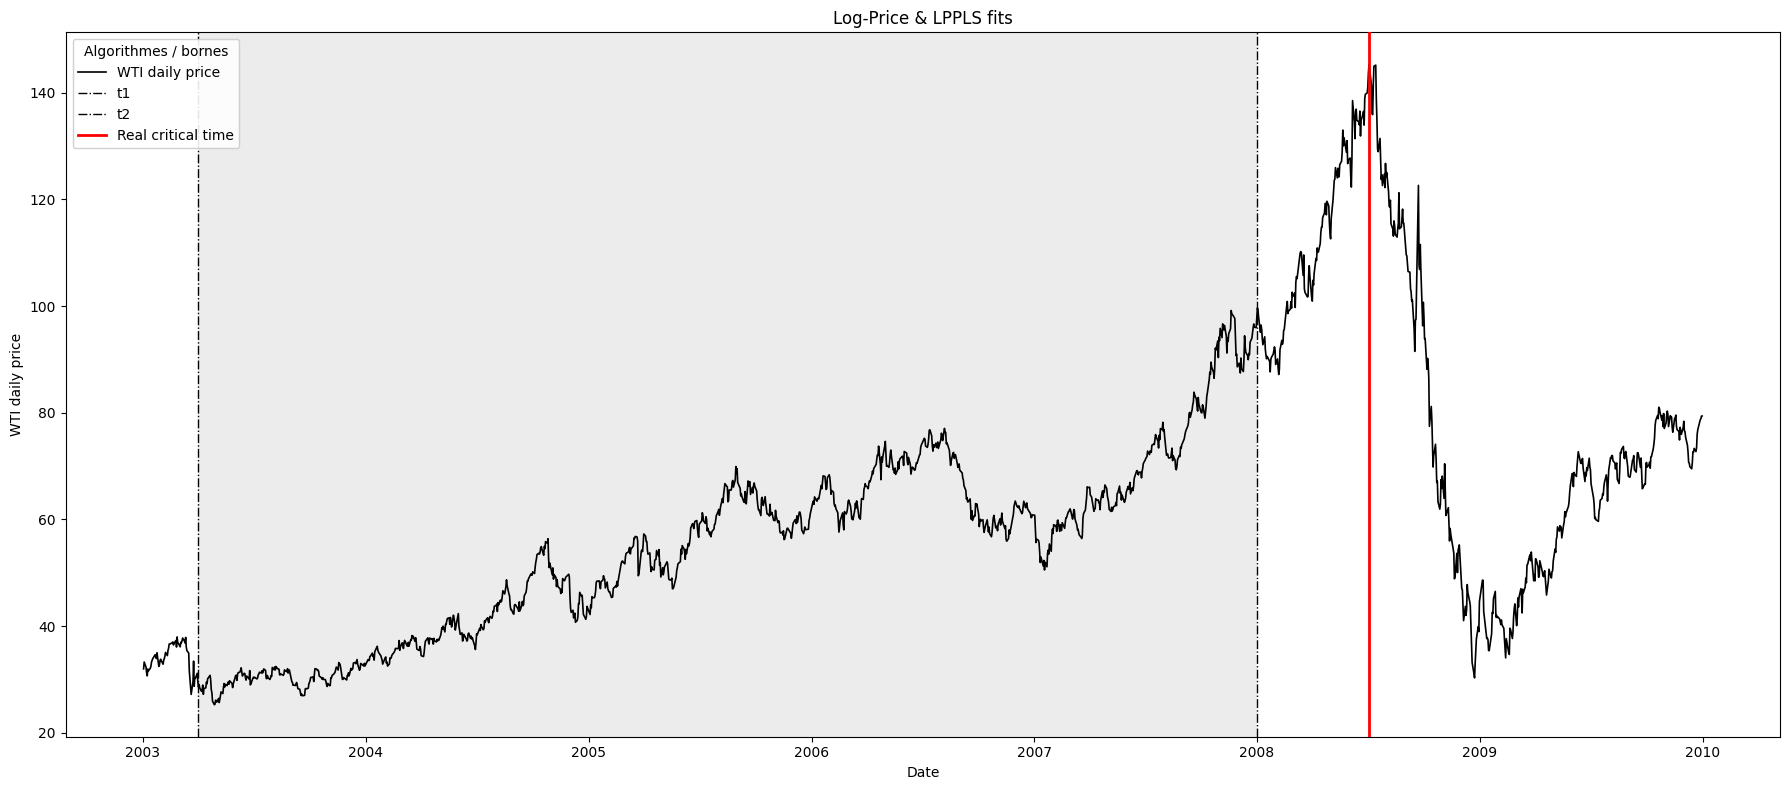

In [1]:
from GQLib.Framework import Framework
from GQLib.enums import InputType
import json

fw = Framework("daily", InputType.WTI)

fig, axes = fw._base("01/04/2003", "02/01/2008", "03/07/2008")

with open("Venise_Results/WTI_metrics.json", "r") as f:
    data = json.load(f)

#fw._add_half_violins(fig, axes, data["Set 1"], specific="tc_distrib_non_significant")
# fw._add_half_violins(fig, axes, data["Set 1"], 
#                         width_scale=0.5,
#                         spacing=0.75,
#                         specific="tc_distrib_non_significant")
# fw._add_half_violins(fig, axes, data["Set 1"], 
#                         width_scale=0.5,
#                         spacing=0.75,
#                         specific="tc_distrib_significant")
fw._add_half_violins(fig, axes, data["Set 1"], 
                        width_scale=0.5,
                        spacing=0.75,
                        specific="tc_distrib_non_significant",
                        hatch_pattern="\\",
                        color="white",
                        text=True,
                        end_date="02/01/2008")
fw._add_half_violins(fig, axes, data["Set 1"], 
                        width_scale=0.5,
                        spacing=0.75,
                        specific="tc_distrib_significant",
                        hatch_pattern="//",
                        color="lightgrey",
                        end_date="02/01/2008")
fw._add_half_violins(fig, axes, data["Set 1"], 
                        width_scale=0.5,
                        spacing=0.75,
                        specific="tc_distrib_significant_power",
                        hatch_pattern="x",
                        color="grey",
                        end_date="02/01/2008")


SP500
Processing Set 1 from 06/03/1995 to 06/03/2000
7
SA
[0.00017264 0.00017666 0.0001806  0.00018444 0.00018819 0.00019183
 0.00019536 0.00019877 0.00020204 0.00020519 0.00020819 0.00021105
 0.00021375 0.00021631 0.0002187  0.00022093 0.000223   0.00022491
 0.00022664 0.00022821 0.00022961 0.00023084 0.00023191 0.00023281
 0.00023354 0.00023412 0.00023454 0.0002348  0.00023492 0.00023489
 0.00023473 0.00023443 0.00023401 0.00023346 0.0002328  0.00023204
 0.00023118 0.00023023 0.00022919 0.00022809 0.00022691 0.00022568
 0.0002244  0.00022308 0.00022173 0.00022035 0.00021896 0.00021756
 0.00021616 0.00021477 0.0002134  0.00021205 0.00021073 0.00020945
 0.00020822 0.00020704 0.00020592 0.00020486 0.00020386 0.00020295
 0.00020211 0.00020135 0.00020068 0.0002001  0.00019962 0.00019923
 0.00019894 0.00019874 0.00019866 0.00019867 0.00019879 0.00019901
 0.00019933 0.00019976 0.00020029 0.00020093 0.00020166 0.0002025
 0.00020343 0.00020446 0.00020557 0.00020678 0.00020807 0.00020945
 0.00

WTI
Processing Set 1 from 01/04/2003 to 02/01/2008
Processing Set 2 from 01/02/2007 to 01/02/2011
Processing Set 3 from 29/04/2011 to 01/08/2015


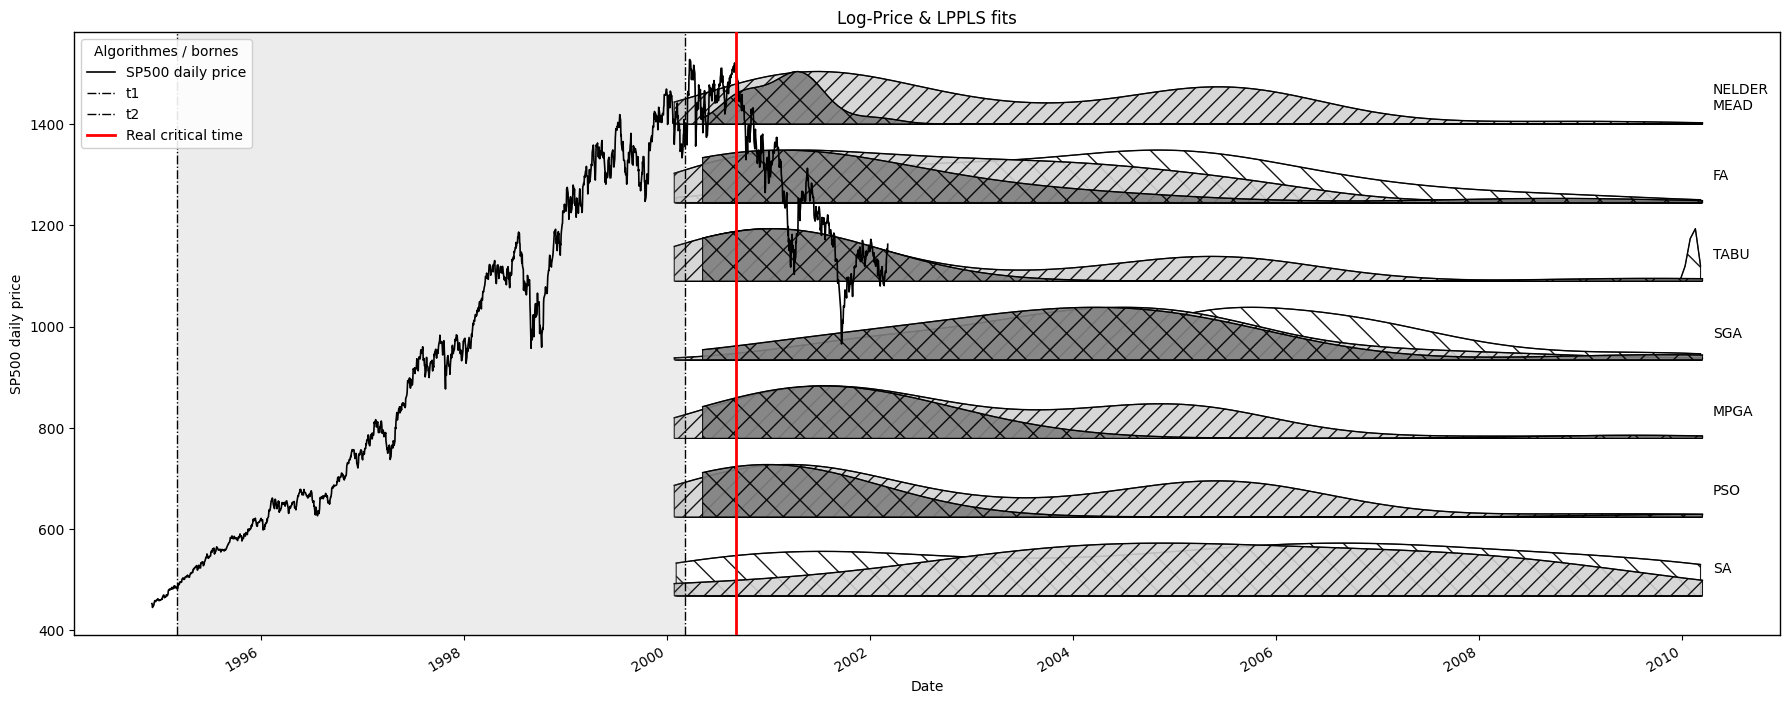

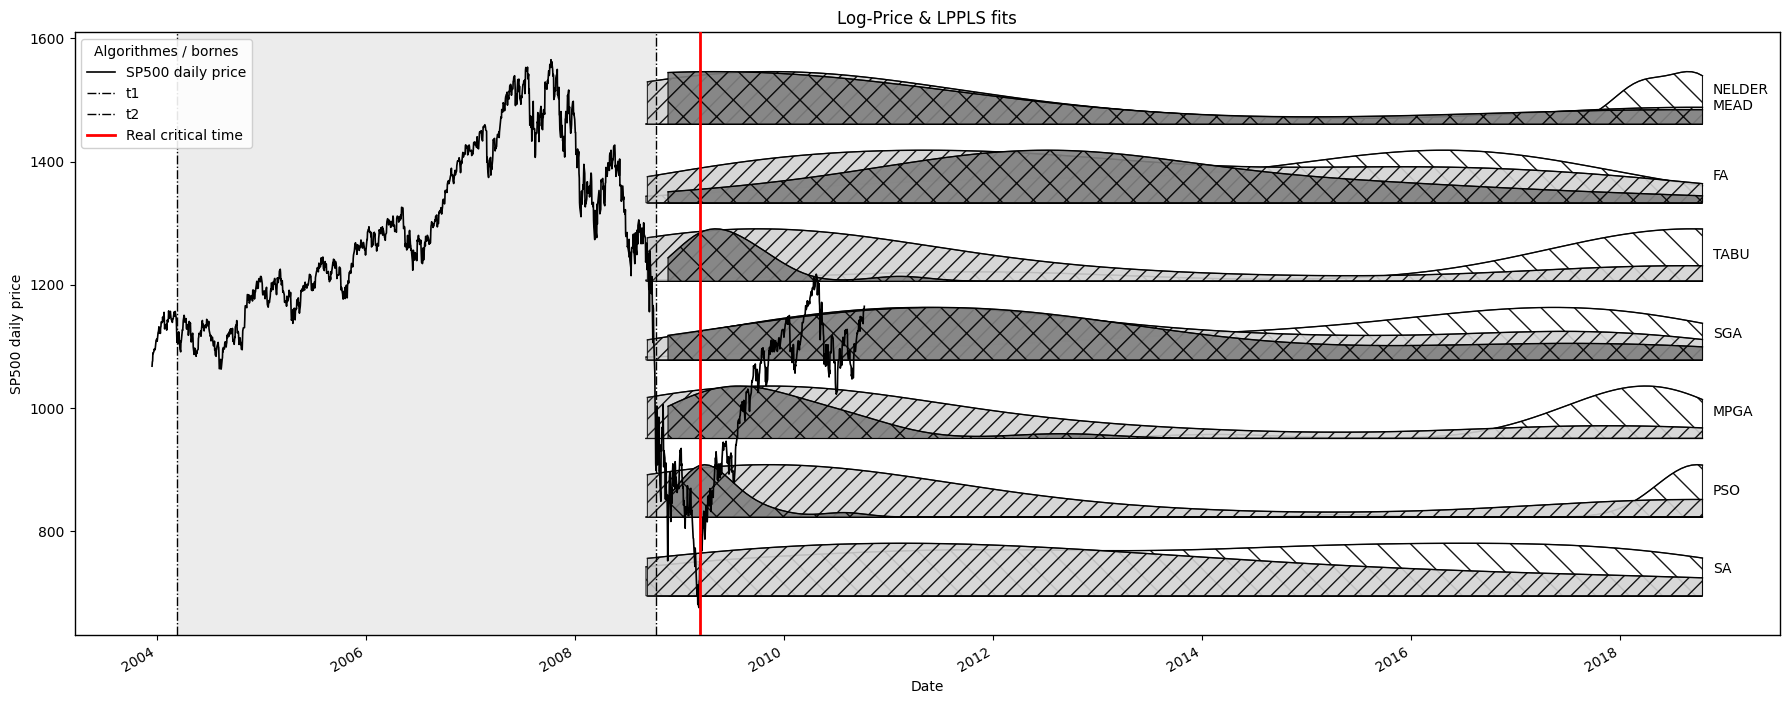

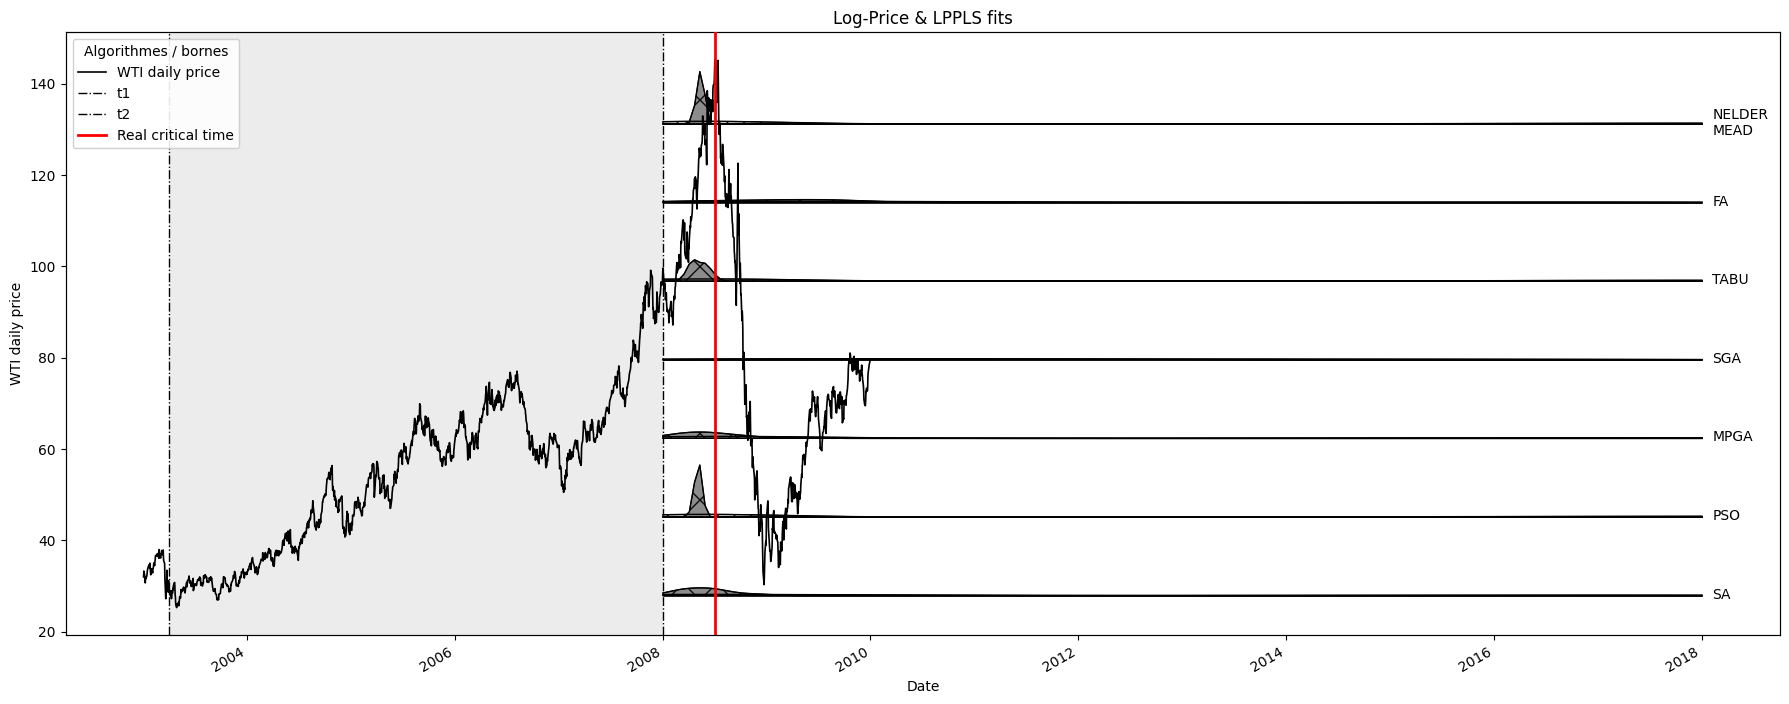

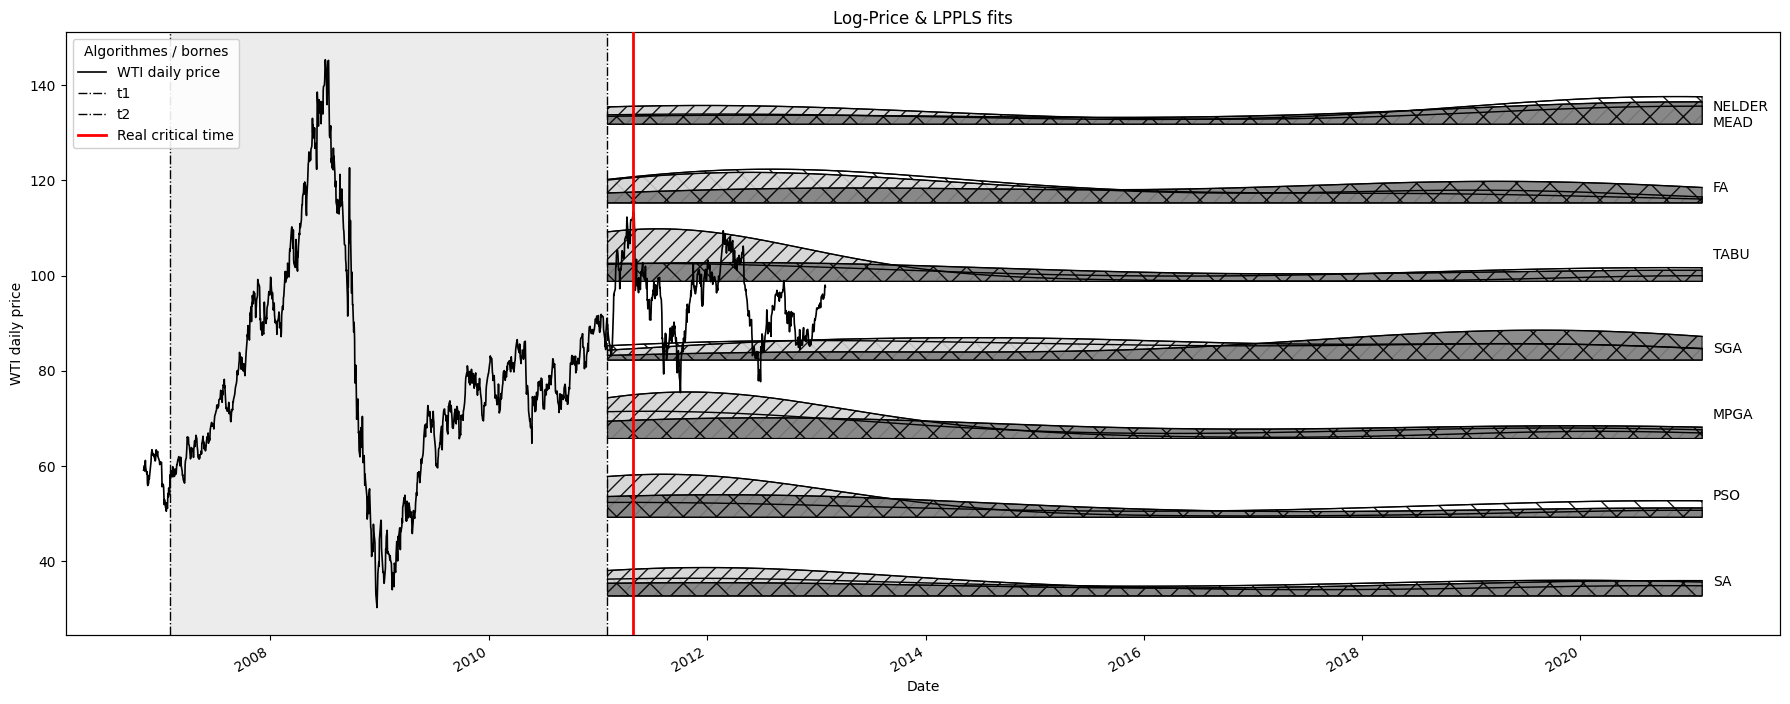

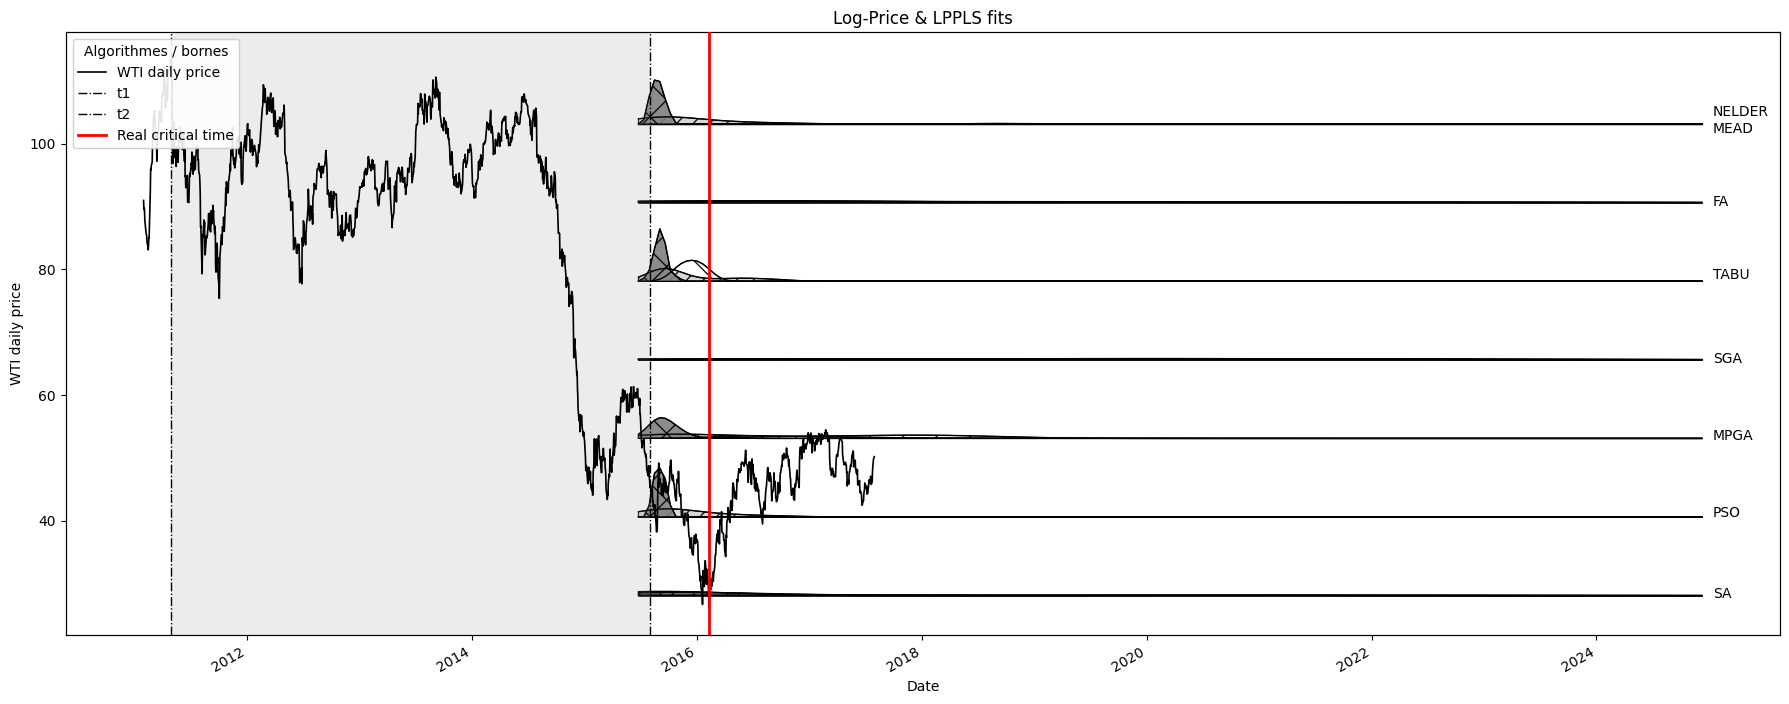

In [ ]:
from GQLib.Framework import Framework
from GQLib.enums import InputType
import json


class Orchestration:
    def __init__(self, input_type):
        self.input_type = input_type
        self.framework = Framework("daily", input_type)
    
        print(self.input_type.value)
        with open(f"Venise_Results_old/{self.input_type.value}_metrics.json", "r") as f:
            self.data = json.load(f)

        with open("params/config.json", "r") as f:
            self.config = json.load(f)

    def run_violons(self, sets: list[str]=None):


        for idx, (key, value) in enumerate(self.config[self.input_type.value]["sets"].items()):
            if sets is not None and key not in sets:
                continue
            start_date, end_date = value
            print(f"Processing {key} from {start_date} to {end_date}")

            real_tc = self.config[self.input_type.value]["real_tcs"][idx]

            fig, axes = self.framework._base(start_date, end_date, real_tc)
        
            fig, axes = self.framework._add_half_violins(fig, axes, self.data[key], 
                                    width_scale=0.5,
                                    spacing=0.75,
                                    specific="tc_distrib_non_significant",
                                    hatch_pattern="\\",
                                    color="white")
            
            fig, axes = self.framework._add_half_violins(fig, axes, self.data[key], 
                                    width_scale=0.5,
                                    spacing=0.75,
                                    specific="tc_distrib_significant",
                                    hatch_pattern="//",
                                    color="lightgrey",
                                    text=True)
            
            fig, axes = self.framework._add_half_violins(fig, axes, self.data[key], 
                                    width_scale=0.5,
                                    spacing=0.75,
                                    specific="tc_distrib_significant_power",
                                    hatch_pattern="x",
                                    color="grey")
            
            fig.show()

    def run_violons_2(self, sets: list[str]=None):

        for idx, (key, value) in enumerate(self.config[self.input_type.value]["sets"].items()):
            if sets is not None and key not in sets:
                continue
            start_date, end_date = value
            print(f"Processing {key} from {start_date} to {end_date}")

            real_tc = self.config[self.input_type.value]["real_tcs"][idx]

            fig, axes = self.framework._base(start_date, end_date, real_tc)

            fig, axes = self.framework._add_multi_half_violins(
                fig, axes,
                self.data[key],
                specifics=[
                    "tc_distrib_non_significant",
                    "tc_distrib_significant",
                    "tc_distrib_significant_power"
                ],
                hatch_patterns=["\\", "//", "x"],
                colors=["white", "lightgrey", "grey"],
                text_flags=[False, True, False],
                width_scale=0.5,
                spacing=0.75,
                limit=end_date
            )

    def run_violons_3(self, sets: list[str]=None):

        for idx, (key, value) in enumerate(self.config[self.input_type.value]["sets"].items()):
            if sets is not None and key not in sets:
                continue
            start_date, end_date = value
            print(f"Processing {key} from {start_date} to {end_date}")

            real_tc = self.config[self.input_type.value]["real_tcs"][idx]

            fig, axes = self.framework._base(start_date, end_date, real_tc)

            fig, axes = self.framework._add_multi_half_violins3(
                fig, axes,
                self.data[key],
                specifics=[
                    "tc_distrib_non_significant",
                    "tc_distrib_significant",
                    "tc_distrib_significant_power"
                ],
                hatch_patterns=["\\", "//", "x"],
                colors=["white", "lightgrey", "grey"],
                text_flags=[False, True, False],
                width_scale=0.5,
                spacing=0.75,
                limit=end_date
            )
    def run_fitted(self, nb: int = 3):

        for idx, (key, value) in enumerate(self.config[self.input_type.value]["sets"].items()):

            start_date, end_date = value

            real_tc = self.config[self.input_type.value]["real_tcs"][idx]

            fig, axes = self.framework._base(start_date, end_date, real_tc)
        
            fig, axes = self.framework._add_lppl_fit(fig, axes, self.data[key], nb_calib=nb, subintervals=True)

# print("\nSP500\n")
o = Orchestration(InputType.SP500)
o.run_violons()
# print("\nWTI\n")
# o = Orchestration(InputType.WTI)
# o.run_violons()
# # #o.run_fitted(5)
# print("\BTC\n")
# o = Orchestration(InputType.BTC)
# o.run_violons()

# print("\nSSE\n")
o = Orchestration(InputType.WTI)
o.run_violons_3()


In [3]:

with open("Venise_Results_old/SP500_metrics.json", "r") as f:
    data = json.load(f)

len(data["Set 2"]['SA']["tc_distrib_significant"])

6

WTI


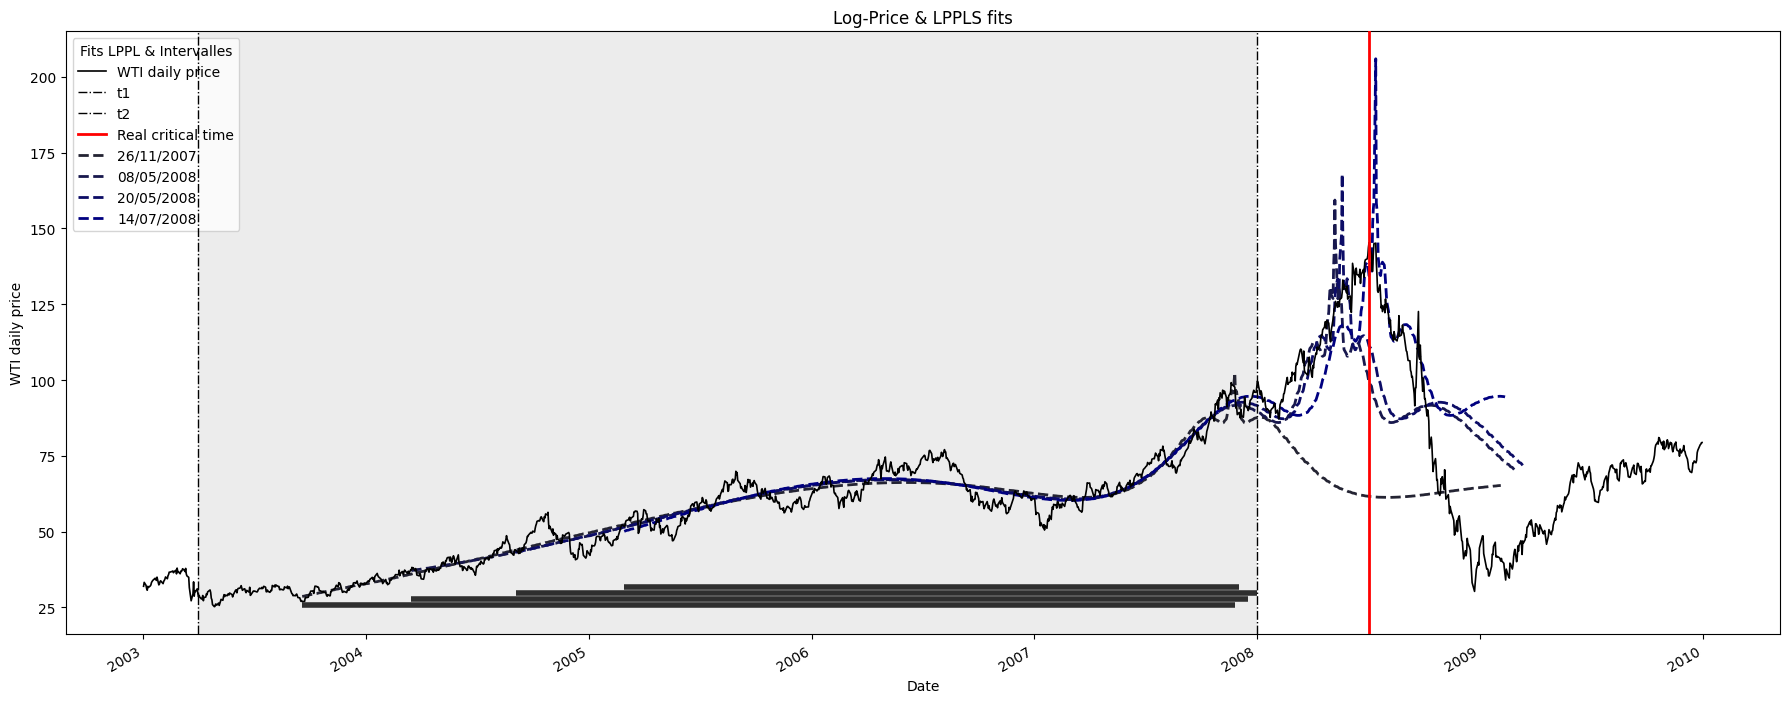

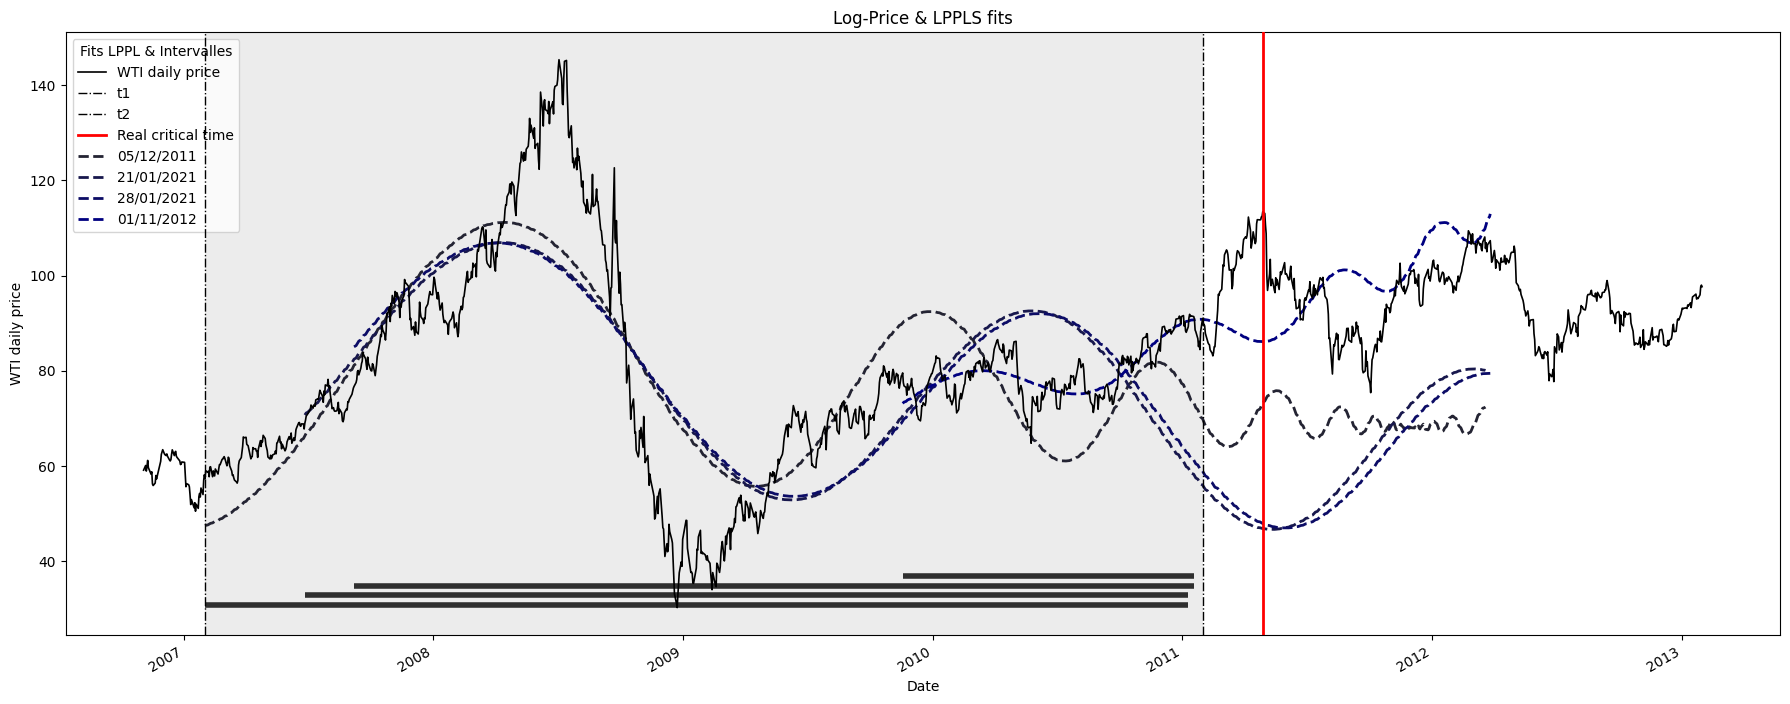

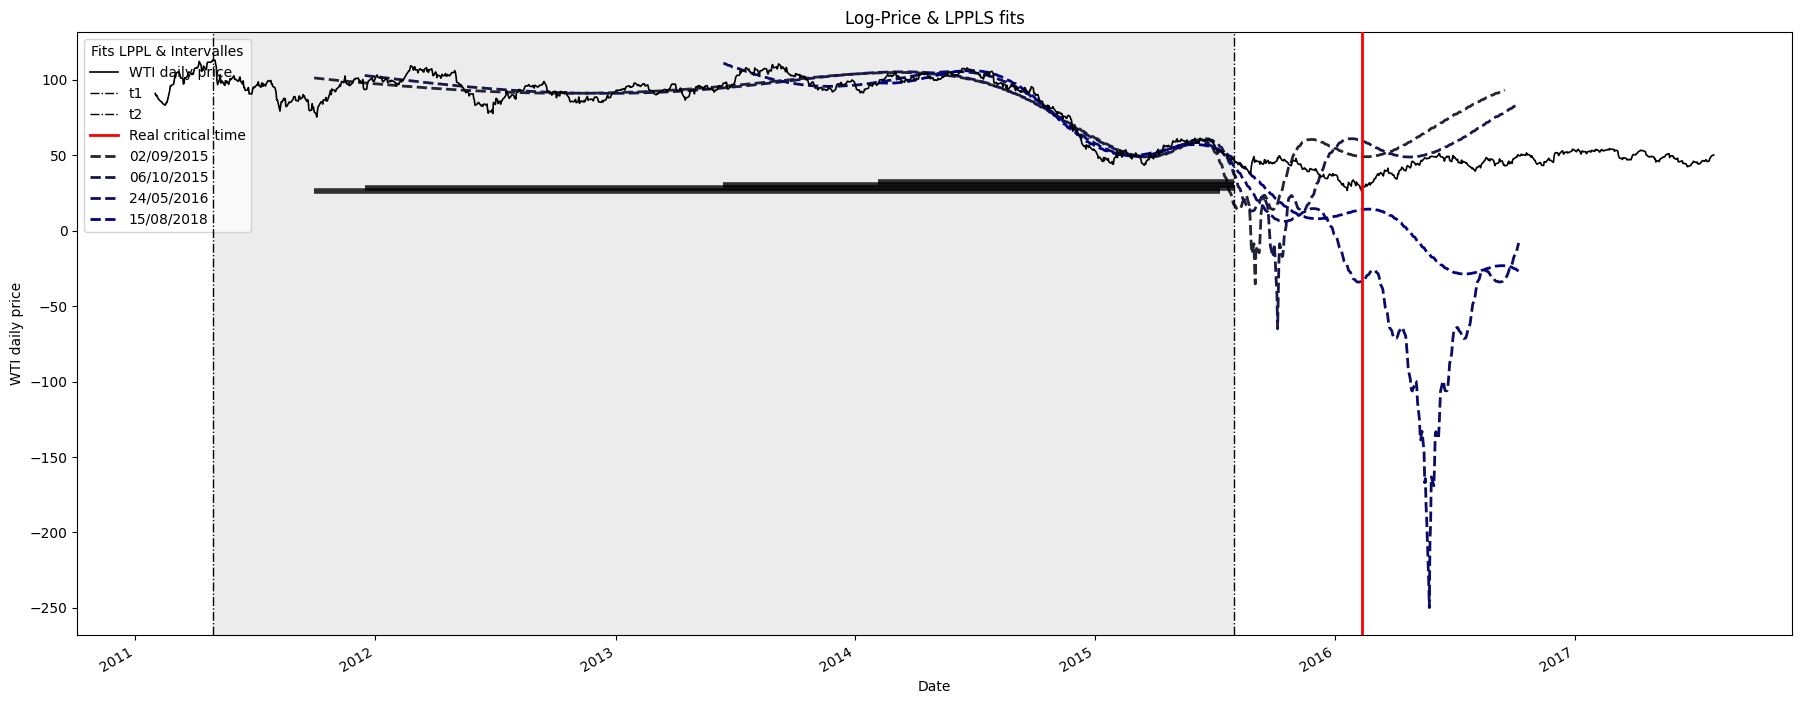

In [8]:
o = Orchestration(InputType.WTI)
o.run_fitted(4)

In [2]:
print("\EURUSD\n")
o = Orchestration(InputType.WTI)
o.run_violons()

\EURUSD



NameError: name 'Orchestration' is not defined

In [7]:
with open("Venise_Results_old/EURUSD_metrics.json", "r") as f:
    data = json.load(f)

data["Set 1"]["PSO"]["tc_distrib_significant_power"]


[2659.7098507333026,
 2729.0,
 2724.0,
 2699.0870786732658,
 2734.0,
 2714.0,
 2729.0,
 2709.0,
 2719.6850324423126,
 2718.3114022088052,
 2671.5692229771466]

(<Figure size 1800x600 with 1 Axes>,
 <Axes: title={'center': 'Log-Price & LPPLS fits'}, xlabel='Date', ylabel='WTI daily price'>)

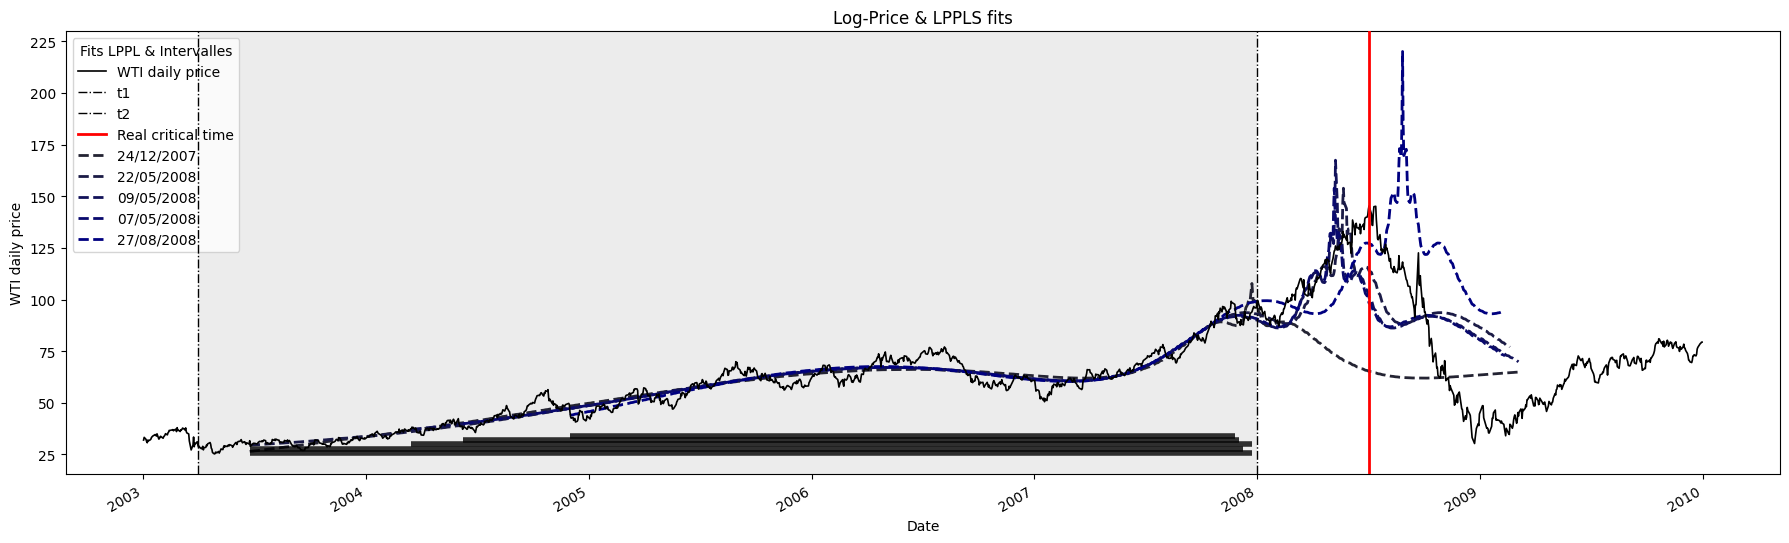

In [2]:
from GQLib.Framework import Framework
from GQLib.enums import InputType
import json


fw = Framework("daily", InputType.WTI)

fig, axes = fw._base("01/04/2003", "02/01/2008", "03/07/2008", width=18, height=6)

with open("Venise_Results_old/WTI_metrics.json", "r") as f:
    data = json.load(f)

fw._add_lppl_fit(fig, axes, data["Set 1"], subintervals=True, nb_calib=5)

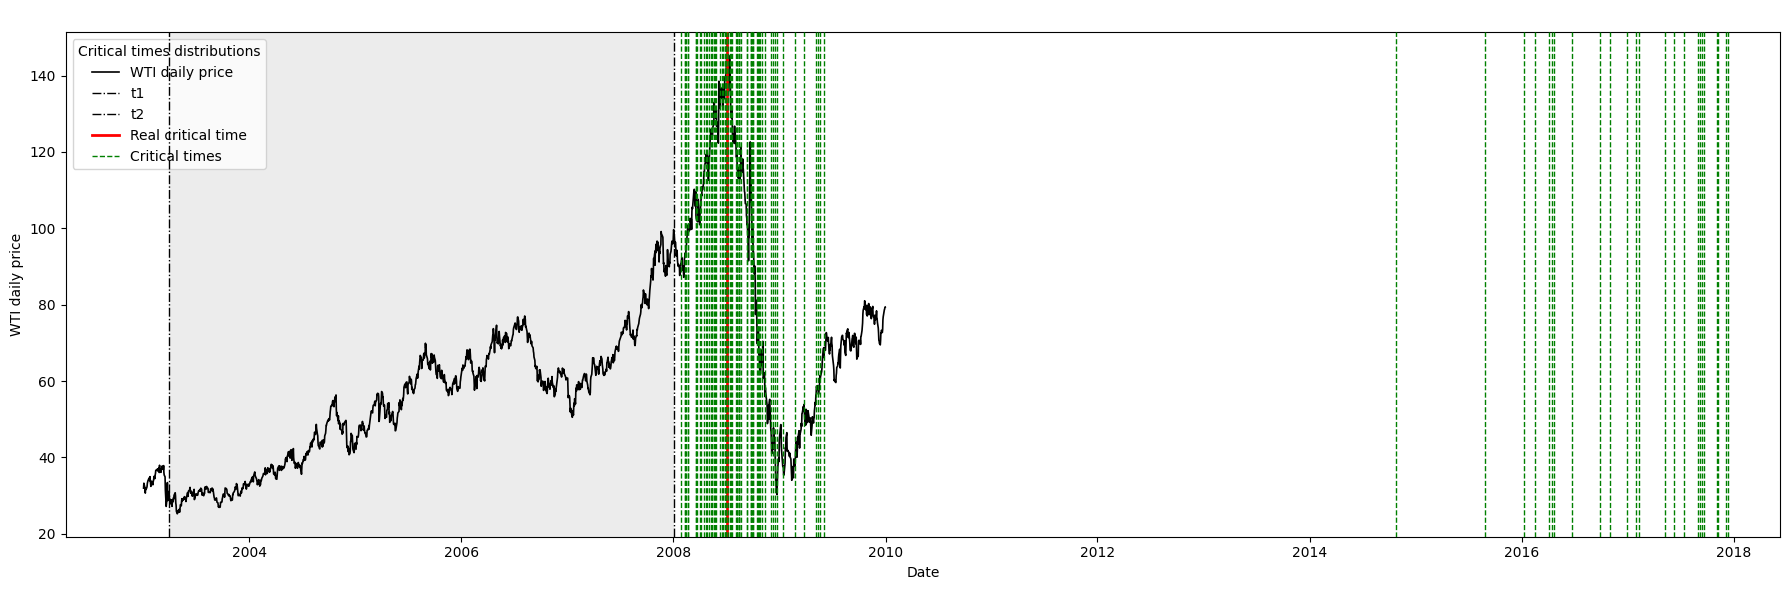

In [1]:
from GQLib.Framework import Framework
from GQLib.enums import InputType
import json


fw = Framework("daily", InputType.WTI)

fig, axes = fw._base("01/04/2003", "02/01/2008", "03/07/2008", width=18, height=6, title=" ")

with open("Venise_Results_old/WTI_metrics.json", "r") as f:
    data = json.load(f)

fig, axes = fw._add_tc(fig, axes, data["Set 1"], algorithm="MPGA")

fig.show()

In [8]:
with open("Venise_Results/WTI_metrics.json", "r") as f:
    data = json.load(f)

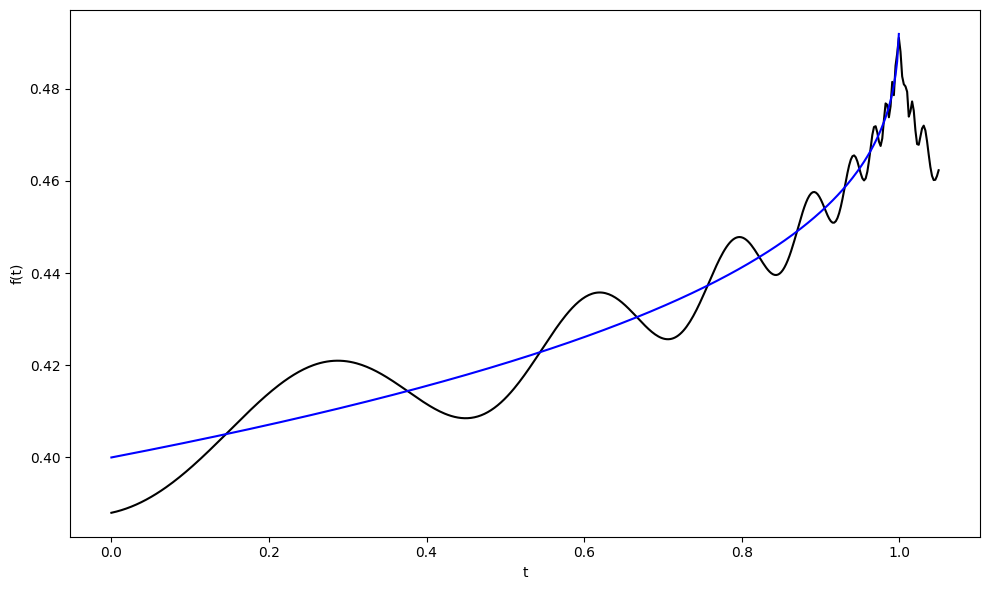

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Définition du modèle LPPL
def lppl(t, tc, A, B, m, C, omega, phi):
    """
    Log-Periodic Power Law: 
    f(t) = A + B*(tc - t)^m * [1 + C*cos(omega*ln(tc - t) + phi)]
    """
    dt = np.abs(tc - t)
    return A + B * dt**m * (1 + C * np.cos(omega * np.log(dt) + phi))

# Paramètres exemples
A     = 0.5
B     = -0.1
m     = 0.33
C     = 0.12
omega = 10.0
phi   = 0.0
tc    = 1.0

# Grille de temps de 0 à 1.1 (éviter la singularité à t=tc)
t = np.linspace(0, 1.05, 500)

# Calcul des courbes
y_total      = lppl(t, tc, A, B, m, C, omega, phi)
y_power_law = A + B * (tc - t)**m

# Tracé
plt.figure(figsize=(10, 6))
plt.plot(t, y_total,      label="LPPL total",  color="black", linewidth=1.5)
plt.plot(t, y_power_law,  label="Power law",   color="blue",  linewidth=1.5)
plt.xlabel("t")
plt.ylabel("f(t)")

plt.tight_layout()
plt.show()

In [3]:

with open("Venise_Results/SSE_metrics.json", "r") as f:
    data = json.load(f)

In [ ]:
from GQLib.Optimizers import MPGA, PSO, SGA, SA, NELDER_MEAD, TABU, FA
from GQLib.Models import LPPL, LPPLS
from GQLib.enums import InputType
from GQLib.AssetProcessor import AssetProcessor
from GQLib.logging import configure_logger
import plotly.io as pio

# Configuration de Plotly pour utiliser le renderer 'browser'
pio.renderers.default = 'browser'

configure_logger("INFO")

wti = AssetProcessor(input_type = InputType.WTI)

wti.compare_optimizers(frequency = "daily",
                            optimizers =  [SA(LPPL)],
                            significativity_tc=0.3,
                            rerun = False,
                            nb_tc = 10,
                            save=False,
                            save_metrics=False,
                            save_plot=False)